# 12 — Embeddings v4: per-lens drift contribution diagnostic

**v2 finding:** lens-space analogies don't survive iteration; cosine flips to ~ -0.27 at k=1.
**v3 finding:** angular sector encoding does NOT fix it (improvement within noise).

**v4 question:** which lens *individually* causes the k=1 sign flip?

For each lens X, compute drift in the lens-X subspace alone:

```
phi_X(c) = Phi(c) * isolate(X)
drift_X(k) = cos(phi_X(b) - phi_X(a), phi_X(T^k b) - phi_X(T^k a))
```

If drift_X(1) is strongly negative for one lens but positive for others, that lens is
the discontinuity source. If multiple lenses flip at k=1, they're collectively
responsible. If none flip but the full Phi does, the flip is an *interaction* effect.

We use the same 60 quads (same seed) as notebooks 10 and 11 for direct comparison.


In [1]:
import sys
sys.path.insert(0, '..')
import random
import numpy as np
import matplotlib.pyplot as plt

from collatz.embeddings import Concept, Phi, T_syracuse
from collatz.embeddings.distance import cosine, ablate_lens
from collatz.embeddings.iteration import _syr_step


## 1. Same quad pool as nb 10 / nb 11


In [2]:
random.seed(7)
N_QUADS = 60

def random_triple(lo, hi):
    return tuple(random.randrange(lo, hi) | 1 for _ in range(3))

def shift(c: Concept) -> Concept:
    return Concept(c.name + "*", tuple(_syr_step(x) for x in c.vec))

quads = []
for i in range(N_QUADS):
    scale = random.choice([10, 50, 200, 1000, 5000])
    a = Concept(f"a{i}", random_triple(2, scale))
    c = Concept(f"c{i}", random_triple(2, scale))
    quads.append((a, shift(a), c, shift(c)))

print(f"{N_QUADS} quads.")


60 quads.


## 2. Build per-lens isolation weights

`ablate_lens(name)` zeros lens `name`'s axes. We want the inverse: keep ONLY lens `name`'s
axes. So `isolate(name) = 1 - ablate_lens(name)`.


In [3]:
LENS_NAMES = ["sector", "mod3", "drop_class", "alpha_prefix", "force", "slope_log"]

def isolate_weights(name: str, m: int = 3) -> np.ndarray:
    return 1.0 - ablate_lens(name, m=m)

# Sanity: the support sizes should match per-component lens sizes (12, 3, 32, 24, 1, 1) * m=3
for name in LENS_NAMES:
    w = isolate_weights(name)
    print(f"  isolate({name:<13}): {int(w.sum())} non-zero axes  (expected: 3 * per-component-size)")


  isolate(sector       ): 36 non-zero axes  (expected: 3 * per-component-size)
  isolate(mod3         ): 9 non-zero axes  (expected: 3 * per-component-size)
  isolate(drop_class   ): 96 non-zero axes  (expected: 3 * per-component-size)
  isolate(alpha_prefix ): 72 non-zero axes  (expected: 3 * per-component-size)
  isolate(force        ): 3 non-zero axes  (expected: 3 * per-component-size)
  isolate(slope_log    ): 3 non-zero axes  (expected: 3 * per-component-size)


## 3. Compute per-lens drift curves


In [4]:
def iterate(c: Concept, k: int) -> Concept:
    for _ in range(k):
        c = T_syracuse(c)
    return c

K = 6  # short horizon; the action is at k=1
drift_per_lens = {name: np.zeros((N_QUADS, K + 1)) for name in LENS_NAMES}
drift_full = np.zeros((N_QUADS, K + 1))

for q_idx, (a, b, c, d) in enumerate(quads):
    base_diff = Phi(b) - Phi(a)
    for k in range(K + 1):
        ak = iterate(a, k)
        bk = iterate(b, k)
        diff_k = Phi(bk) - Phi(ak)
        # full
        drift_full[q_idx, k] = cosine(diff_k, base_diff)
        # per-lens: project both diff vectors onto the lens subspace
        for name in LENS_NAMES:
            w = isolate_weights(name)
            drift_per_lens[name][q_idx, k] = cosine(diff_k * w, base_diff * w)

print(f"{'lens':<14} {'k=1 cos':>10} {'k=1 flips':>12} {'mean k=1..K':>14}")
print("-" * 53)
print(f"{'(full Phi)':<14} {drift_full[:, 1].mean():>10.3f} {(drift_full[:, 1] < 0).sum():>12d} {drift_full[:, 1:].mean():>14.3f}")
for name in LENS_NAMES:
    d = drift_per_lens[name]
    print(f"{name:<14} {d[:, 1].mean():>10.3f} {(d[:, 1] < 0).sum():>12d} {d[:, 1:].mean():>14.3f}")


lens              k=1 cos    k=1 flips    mean k=1..K
-----------------------------------------------------
(full Phi)         -0.267           47         -0.071
sector             -0.486           60         -0.081
mod3               -0.292           37         -0.068
drop_class         -0.405           51         -0.069
alpha_prefix       -0.406           59         -0.072
force              -0.086           31         -0.047
slope_log          -0.325           38         -0.034


## 4. Plot per-lens drift curves


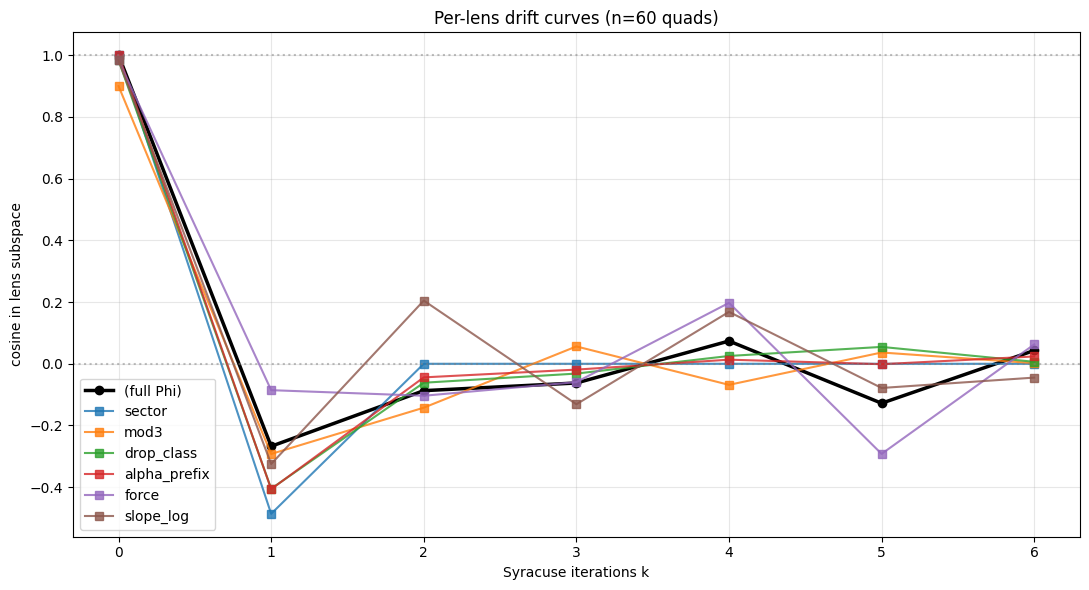

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
ks = np.arange(K + 1)

# baseline
mean = drift_full.mean(axis=0)
ax.plot(ks, mean, marker="o", color="black", label="(full Phi)", linewidth=2.5)

palette = {
    "sector": "tab:blue",
    "mod3": "tab:orange",
    "drop_class": "tab:green",
    "alpha_prefix": "tab:red",
    "force": "tab:purple",
    "slope_log": "tab:brown",
}
for name in LENS_NAMES:
    mean = drift_per_lens[name].mean(axis=0)
    ax.plot(ks, mean, marker="s", color=palette[name], label=name, linewidth=1.5, alpha=0.8)

ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax.axhline(1, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Syracuse iterations k")
ax.set_ylabel("cosine in lens subspace")
ax.set_title(f"Per-lens drift curves (n={N_QUADS} quads)")
ax.legend(loc="lower left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Verdict template

Read off the table:

- **One lens has k=1 cosine strongly negative, others positive** -> that lens is the
  discontinuity source. Targeted fix possible (smoother encoding, normalization, removal).
- **Multiple lenses flip at k=1** -> distributed discontinuity. Smooth encodings won't
  fix it; need a different metric or trajectory-space (Approach B).
- **All per-lens curves stay positive but full-Phi flips** -> the flip is an *interaction
  effect* between lenses. Probably a normalization issue: real-valued lenses (force,
  slope_log) dominate norms differently after iteration than at k=0, so cosine on the
  combined vector goes negative even though each subspace is fine.
